In [1]:
import hypertools as hyp
import numpy as np
import random
import os
from scipy.spatial.distance import pdist, squareform
from matplotlib import pyplot as plt
from umap import UMAP
import seaborn as sns

%matplotlib inline

In [2]:
norm_term = 1000
ep_model_dir = '../../data/models/episodes/t100_w50/'
ep_traj_dir = os.path.join(ep_model_dir, 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 'events')
ep_emb_dir = os.path.join(ep_model_dir, 'embeddings', 'k:'+str(norm_term))
opt_ep_dir = os.path.join(ep_emb_dir, 'optimized')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:'+str(norm_term))
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings', 'k:'+str(norm_term))
opt_rec_dir = os.path.join(rec_emb_dir, 'optimized')
pickle_dir = '../../data/pickles/'

In [3]:
# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

In [4]:
for rectype in avg_participant_events.keys():
    no_rec_mask = np.all(np.equal(avg_participant_events[rectype], 0), axis=1)
    avg_participant_events[rectype] = avg_participant_events[rectype][~no_rec_mask]

In [5]:
#source: https://stackoverflow.com/questions/563198/how-do-you-detect-where-two-line-segments-intersect
def segments_intersect2d(a1, b1, a2, b2):
    s1 = b1 - a1
    s2 = b2 - a2
    
    s = (-s1[1] * (a1[0] - a2[0]) + s1[0] * (a1[1] - a2[1])) / (-s2[0] * s1[1] + s1[0] * s2[1])
    t = ( s2[0] * (a1[1] - a2[1]) - s2[1] * (a1[0] - a2[0])) / (-s2[0] * s1[1] + s1[0] * s2[1])
    
    if (s >= 0) and (s <= 1) and (t >= 0) and (t <= 1):
        return True
    else:
        return False

In [6]:
def n_intersections(x):
    intersections = 0
    points = []
    for i in np.arange(x.shape[0] - 1):
        a1 = x[i, :]
        b1 = x[i+1, :]
        for j in np.arange(i+2, x.shape[0] - 1):
            a2 = x[j, :]
            b2 = x[j+1, :]
            
            if segments_intersect2d(a1, b1, a2, b2):           
                intersections += 1
    return intersections

In [7]:
data_concat = {k : None for k in participant_events.keys()}
for rectype in data_concat.keys():
    if rectype == 'delayed':
        rt = 'atlep1'
    elif rectype == 'prediction':
        rt = 'atlep2'
    else:
        rt = rectype
    data = [episode_events[rt], avg_participant_events[rectype]]
    for tid, p in participant_events[rectype]:
        data.append(p)
    data_concat[rectype] = data

In [8]:
start = 2500
n_seeds = 2500
seeds = np.arange(start, start + n_seeds)

In [9]:
seed_dists = {k : None for k in data_concat.keys()}

for rectype, data in data_concat.items():
    if rectype == 'arrdev':
        intersections = np.zeros(len(seeds))
        intersections_ep = np.zeros(len(seeds))
        print(rectype)
        for i, s in enumerate(seeds):
            if not s % 50:
                print(s)
            next_reduced = hyp.reduce(data, reduce={'model':'UMAP', 'params': {'random_state': s}}, ndims=2)
            intersections[i] = np.sum([n_intersections(x) for x in next_reduced])
            intersections_ep[i] = n_intersections(next_reduced[0])

        seed_dists[rectype] = {'intersections' : intersections, 'intersections_ep' : intersections_ep}

2500
2501
2502
2503
2504
2505
2506
2507
2508
2509
2510
2511
2512
2513
2514
2515
2516
2517
2518
2519
2520
2521
2522
2523
2524
2525
2526
2527
2528
2529
2530
2531
2532
2533
2534
2535
2536
2537
2538
2539
2540
2541
2542
2543
2544
2545
2546
2547
2548
2549
2550
2551
2552
2553
2554
2555
2556
2557
2558
2559
2560
2561
2562
2563
2564
2565
2566
2567
2568
2569
2570
2571
2572
2573
2574
2575
2576
2577
2578
2579
2580
2581
2582
2583
2584
2585
2586
2587
2588
2589
2590
2591
2592
2593
2594
2595
2596
2597
2598
2599
2600
2601
2602
2603
2604
2605
2606
2607
2608
2609
2610
2611
2612
2613
2614
2615
2616
2617
2618
2619
2620
2621
2622
2623
2624
2625
2626
2627
2628
2629
2630
2631
2632
2633
2634
2635
2636
2637
2638
2639
2640
2641
2642
2643
2644
2645
2646
2647
2648
2649
2650
2651
2652
2653
2654
2655
2656
2657
2658
2659
2660
2661
2662
2663
2664
2665
2666
2667
2668
2669
2670
2671
2672
2673
2674
2675
2676
2677
2678
2679
2680
2681
2682
2683
2684
2685
2686
2687
2688
2689
2690
2691
2692
2693
2694
2695
2696
2697
2698
2699


4139
4140
4141
4142
4143
4144
4145
4146
4147
4148
4149
4150
4151
4152
4153
4154
4155
4156
4157
4158
4159
4160
4161
4162
4163
4164
4165
4166
4167
4168
4169
4170
4171
4172
4173
4174
4175
4176
4177
4178
4179
4180
4181
4182
4183
4184
4185
4186
4187
4188
4189
4190
4191
4192
4193
4194
4195
4196
4197
4198
4199
4200
4201
4202
4203
4204
4205
4206
4207
4208
4209
4210
4211
4212
4213
4214
4215
4216
4217
4218
4219
4220
4221
4222
4223
4224
4225
4226
4227
4228
4229
4230
4231
4232
4233
4234
4235
4236
4237
4238
4239
4240
4241
4242
4243
4244
4245
4246
4247
4248
4249
4250
4251
4252
4253
4254
4255
4256
4257
4258
4259
4260
4261
4262
4263
4264
4265
4266
4267
4268
4269
4270
4271
4272
4273
4274
4275
4276
4277
4278
4279
4280
4281
4282
4283
4284
4285
4286
4287
4288
4289
4290
4291
4292
4293
4294
4295
4296
4297
4298
4299
4300
4301
4302
4303
4304
4305
4306
4307
4308
4309
4310
4311
4312
4313
4314
4315
4316
4317
4318
4319
4320
4321
4322
4323
4324
4325
4326
4327
4328
4329
4330
4331
4332
4333
4334
4335
4336
4337
4338


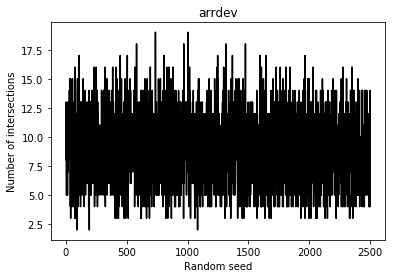

In [11]:
for rectype, sds in seed_dists.items():
    if rectype == 'arrdev':
        plt.plot(np.arange(0, n_seeds), sds['intersections_ep'], color='k')
        plt.title(rectype)
        plt.xlabel('Random seed')
        plt.ylabel('Number of intersections')

arrdev seed: 2590 episode intersections: 2.0


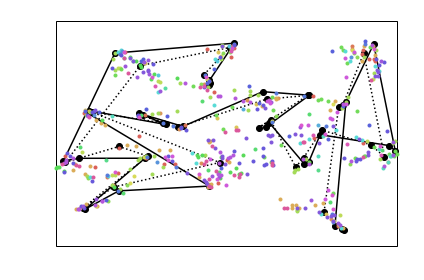

In [13]:
#reduction with the fewest intersections
# s = seeds[np.argmin(intersections_video)]
# next_reduced = hyp.reduce(data, reduce={'model':'UMAP', 'params': {'random_state': s}}, ndims=2)
# styles = ['ko-', 'ko:']; styles.extend(['.']*(len(next_reduced)-2))
# hyp.plot(next_reduced, styles)

#reduction with the fewest intersections
for rectype, sds in seed_dists.items():
    if rectype == 'arrdev':
        s = seeds[np.argmin(sds['intersections_ep'])]
        print(rectype, f'seed: {s}', f'episode intersections: {np.min(sds["intersections_ep"])}')
        next_reduced = hyp.reduce(data_concat[rectype], reduce={'model':'UMAP', 'params': {'random_state': s}}, ndims=2)
        styles = ['ko-', 'ko:']; styles.extend(['.']*(len(next_reduced)-2))
        hyp.plot(next_reduced, styles)

#         np.save(os.path.join(opt_ep_dir, rectype, f'{rectype}_events.npy'), next_reduced[0])
#         np.save(os.path.join(opt_rec_dir, rectype, 'avg_participant_events.npy'), next_reduced[1])
#         for (tid, _), emb in zip(participant_events[rectype], next_reduced[2:]):
#             np.save(os.path.join(opt_rec_dir, rectype, f'{tid}.npy'), emb)

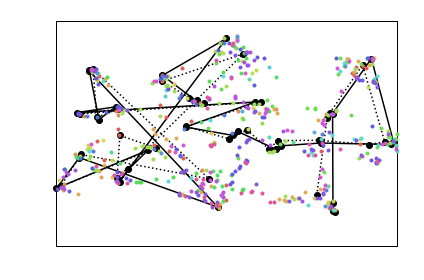

In [14]:
for rectype, sds in seed_dists.items():
    if rectype == 'arrdev':
        s = seeds[np.argmax(sds['intersections'])]
        next_reduced = hyp.reduce(data_concat[rectype], reduce={'model':'UMAP', 'params': {'random_state': s}}, ndims=2)
        hyp.plot(next_reduced, styles)

Text(34.0, 0.5, 'Time')

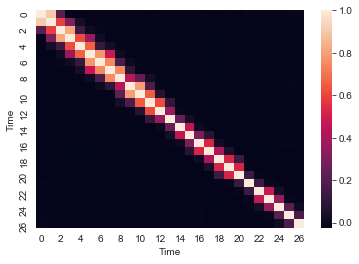

In [74]:
# sns.heatmap(1 - squareform(pdist(episode_events, 'correlation')))
# plt.xlabel('Time')
# plt.ylabel('Time')

Text(34.0, 0.5, 'Time')

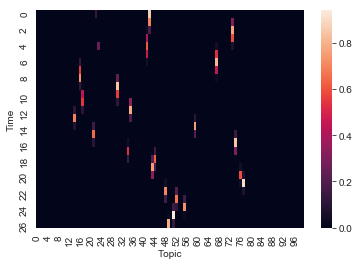

In [75]:
# sns.heatmap(episode_events)
# plt.xlabel('Topic')
# plt.ylabel('Time')

In [76]:
for rectype, sds in seed_dists.items():
    if rectype == 'arrdev':
        print(f'{rectype}: best random seed (fewest episode intersections) = \
        {seeds[np.argmin(sds["intersections_ep")]}')

This one seems best: random seed = 4492, optimized using the minimum number of intersections
